In [1]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("retail_sales_dataset.csv")

# 2. Basic Inspection
print("--- Dataset Info ---")
print(df.info())

# 3. Data Cleaning: Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 4. Data Cleaning: Check for duplicate records
print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

# 5. Data Formatting: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

print("\nStep 1 Complete: Data is loaded and cleaned!")
df.head()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None

--- Missing Values ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Duplicate Rows ---
0

Step 1 Complete: Data is loaded and cleaned!


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# 1. Calculate basic statistics for numerical columns
stats_summary = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe()

# 2. Calculate the Mode (describe doesn't include mode)
mode_values = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode().iloc[0]

# 3. Print the results
print("--- Statistical Summary ---")
print(stats_summary)

print("\n--- Mode Values ---")
print(mode_values)

--- Statistical Summary ---
              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000

--- Mode Values ---
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


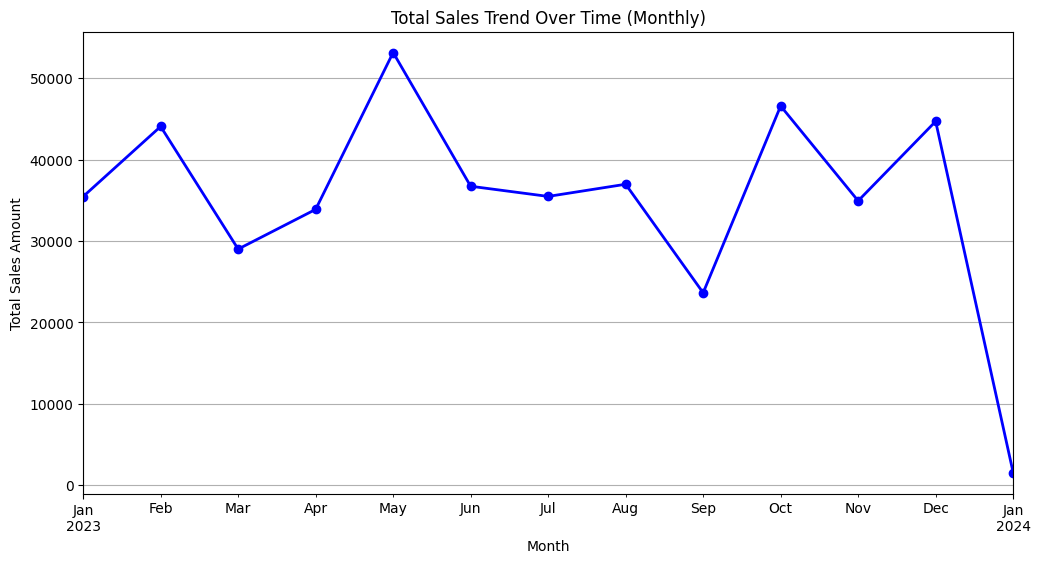

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Reload/Ensure data is present
df = pd.read_csv("retail_sales_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])

# 2. Group by Month - as required by the project proposal
# [span_1](start_span)This calculates total sales for each month[span_1](end_span)
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# 3. [span_2](start_span)Visualization - Plotting trends[span_2](end_span)
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='blue', linewidth=2)

plt.title('Total Sales Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.show()

C:\Users\Ashish\AppData\Local\Temp\ipykernel_8956\787076327.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.index, y=product_sales.values, palette='viridis')


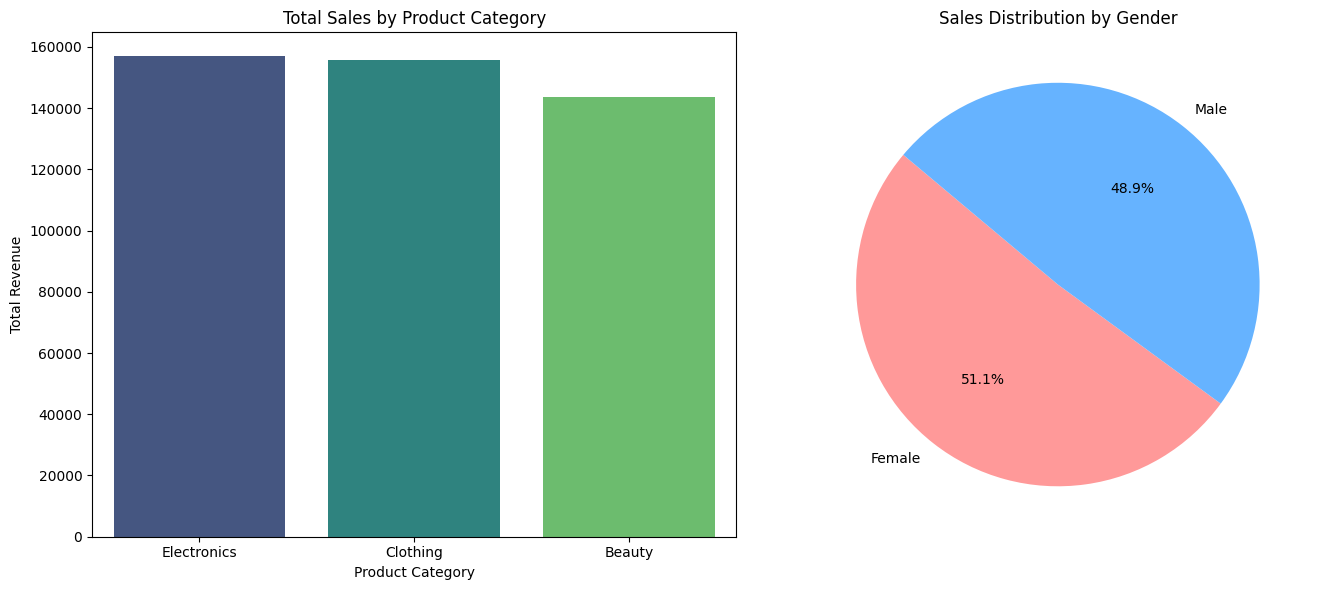

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Product Analysis: Total Sales by Product Category
product_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# 2. Gender Analysis: Total Sales by Gender
gender_sales = df.groupby('Gender')['Total Amount'].sum()

# 3. Visualization
plt.figure(figsize=(14, 6))

# Subplot 1: Bar Chart for Product Categories
plt.subplot(1, 2, 1)
sns.barplot(x=product_sales.index, y=product_sales.values, palette='viridis')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

# Subplot 2: Pie Chart for Gender Distribution
plt.subplot(1, 2, 2)
plt.pie(gender_sales, labels=gender_sales.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Sales Distribution by Gender')

plt.tight_layout()
plt.show()

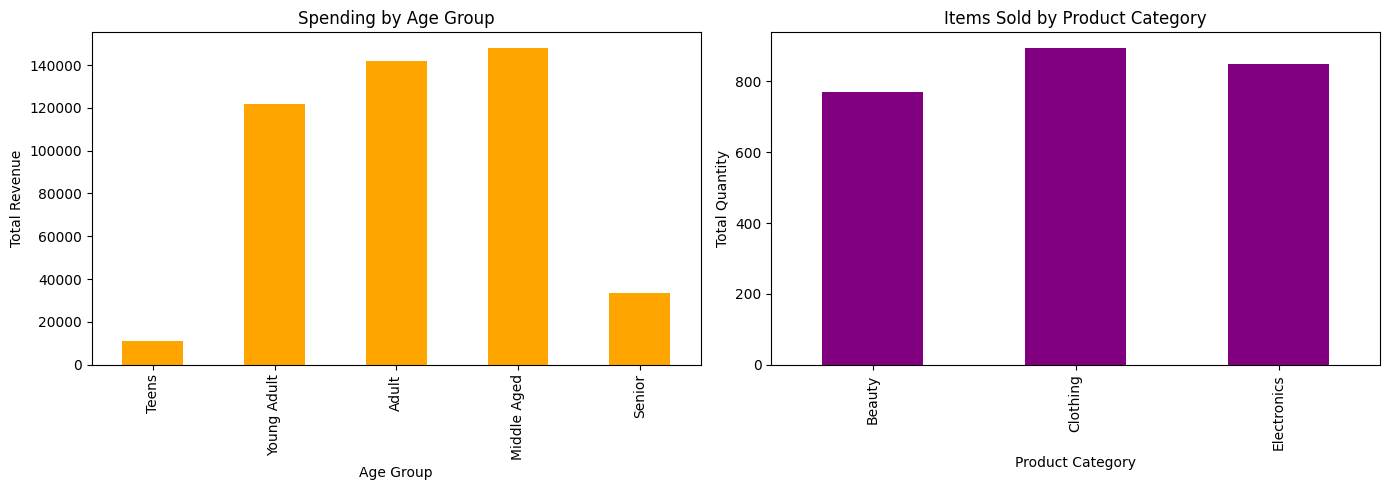

--- Final Insights ---
Top Category by Revenue: Electronics
Top Spending Gender: Female
Highest Spending Age Group: Middle Aged


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Age Analysis: Create age bins to see which group is most active
df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100], labels=['Teens', 'Young Adult', 'Adult', 'Middle Aged', 'Senior'])
age_spending = df.groupby('Age Group')['Total Amount'].sum()

# 2. Quantity Analysis: Which category sells the MOST items?
product_qty = df.groupby('Product Category')['Quantity'].sum()

# 3. Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
age_spending.plot(kind='bar', color='orange')
plt.title('Spending by Age Group')
plt.ylabel('Total Revenue')

plt.subplot(1, 2, 2)
product_qty.plot(kind='bar', color='purple')
plt.title('Items Sold by Product Category')
plt.ylabel('Total Quantity')

plt.tight_layout()
plt.show()

# Final Summary for your report
print("--- Final Insights ---")
print(f"Top Category by Revenue: {product_sales.idxmax()}")
print(f"Top Spending Gender: {gender_sales.idxmax()}")
print(f"Highest Spending Age Group: {age_spending.idxmax()}")